# Part I - Ford GoBike System Data Analysis
## by Hanna Abudayeh

## Introduction

## Preliminary Wrangling

In [17]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib.ticker import ScalarFormatter

In [18]:
df = pd.read_csv('201902-fordgobike-tripdata.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [19]:
# checking and Removing Rows with missing data
df = df.dropna()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174952 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             174952 non-null  int64  
 1   start_time               174952 non-null  object 
 2   end_time                 174952 non-null  object 
 3   start_station_id         174952 non-null  float64
 4   start_station_name       174952 non-null  object 
 5   start_station_latitude   174952 non-null  float64
 6   start_station_longitude  174952 non-null  float64
 7   end_station_id           174952 non-null  float64
 8   end_station_name         174952 non-null  object 
 9   end_station_latitude     174952 non-null  float64
 10  end_station_longitude    174952 non-null  float64
 11  bike_id                  174952 non-null  int64  
 12  user_type                174952 non-null  object 
 13  member_birth_year        174952 non-null  float64
 14  member_ge

In [21]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,2019-02-28 23:49:58.6320,2019-03-01 00:19:51.7600,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No


### What is the structure of your dataset?

> It's in a CSV Structure and the dataset contains 174952 rows and 16 columns.

### What is/are the main feature(s) of interest in your dataset?

> These are the main features of interest:
*   **duration_sec** The duration of the bike trip in seconds
*   **user_type** Shows if the rider is a subscriber or a customer
*   **member_gender** Shows the gender of the rider.
*   **bike_share_for_all_trip** Indicates whether the trip was part of the "Bike Share for All" program, helping to study program utilization.
*   **member_birth_year** Shows when the rider was born
*   **start_station_latitude** The beginning position's latitude
*   **start_station_longitude** The beginning position's longitude
*   **start_station_id** The id of the bike station where the trip started
*   **end_station_id** The id of the bike station where the trip ended
*   **end_station_latitude** The end position's latitude
*   **end_station_latitude** The end position's latitude


### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

*   **user_type** To understand behavioral differences between subscribers and customers.
*   **member_gender** To analyze usage patterns based on gender.
*   **bike_share_for_all_trip** To evaluate the impact of the program on trip durations and user engagement.
*   **start_time and end_time** To analyze time-based trends, such as trip durations across different times of the day or days of the week.
*   **member_birth_year** This can be transformed into an age feature to explore age-related patterns in trip durations.

## Univariate Exploration

### Question 1: How are user types distributed?
How are user types distributed?

<Axes: xlabel='user_type', ylabel='count'>

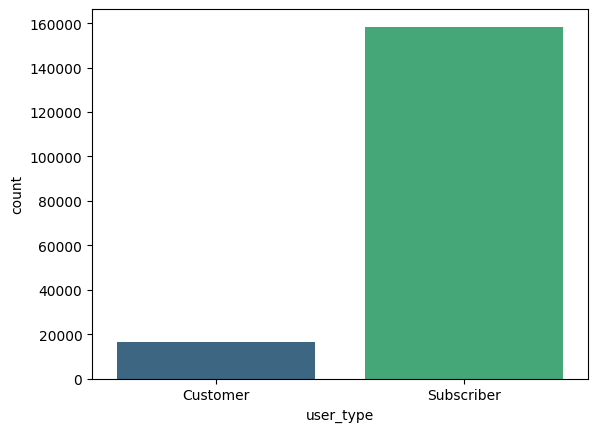

In [22]:
sns.countplot(data=df, x='user_type', hue='user_type', palette='viridis')

there are more subscribers than customers in this dataset.

### Question 2: What is the distribution of trip durations?
What is the distribution of trip durations?

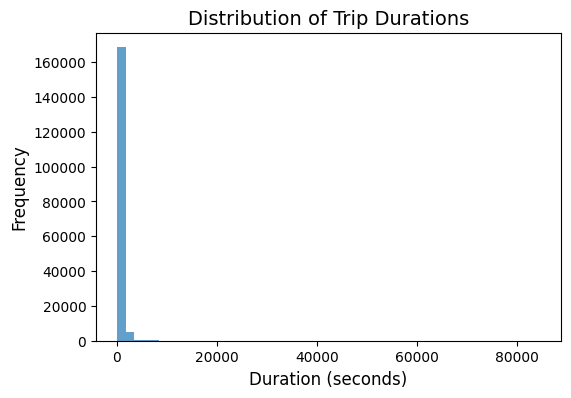

In [23]:
plt.figure(figsize=(6, 4))
plt.hist(df['duration_sec'], bins=50, alpha=0.7)
plt.title('Distribution of Trip Durations', fontsize=14)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

The majority of the trips have short durations, with a long tail for longer durations Extreme outliers might exist for very long trips.

### Question 3: What is the distribution of member genders?
What is the distribution of member genders?

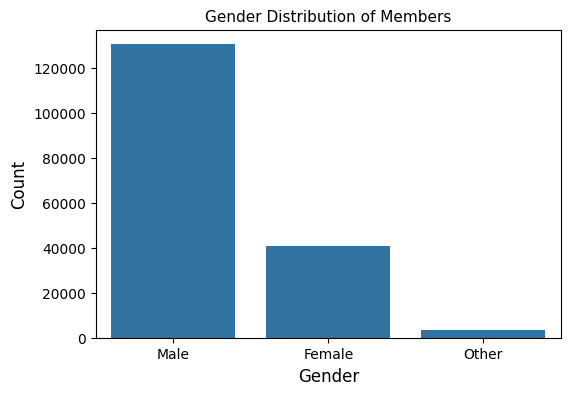

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='member_gender', order=['Male', 'Female', 'Other'])
plt.title('Gender Distribution of Members', fontsize=11)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

The majority of riders are male, followed by females and others.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> The distribution of the duration_sec variable is highly right-skewed, with most bike trips lasting under 1,000 seconds (around 16 minutes). However, there are extreme outliers, with some trips recorded as lasting up to 80,000 seconds (approximately 22 hours). Such unusually long durations are likely the result of data entry errors, system issues, or exceptional cases like unreturned bikes. While no transformations have been applied yet, applying a log scale or filtering out these outliers may be necessary to improve the clarity of future visualizations and analyses.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> The duration_sec variable shows a highly skewed distribution, with a small number of extremely long trips. To address this skewness, one possible approach is to filter out outliers exceeding a reasonable threshold (e.g., trips longer than a few hours). Alternatively, applying a log transformation could help normalize the distribution for more effective analysis. Among the categorical variables, features like user_type and member_gender appear to have relatively balanced distributions. However, some records contain missing values—particularly in member_gender—which may require imputation or removal, depending on the goals of the analysis.

## Bivariate Exploration


### Question 1: How does trip duration vary by user type?

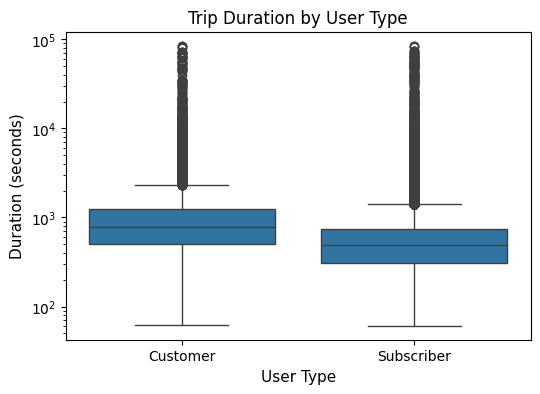

In [25]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='user_type', y='duration_sec')
plt.title('Trip Duration by User Type', fontsize=12)
plt.xlabel('User Type', fontsize=11)
plt.ylabel('Duration (seconds)', fontsize=11)
plt.yscale('log')
plt.show()


**Observations:**

Trip Duration Differences:

Customers tend to take longer trips than Subscribers, as reflected by their higher median trip duration. Additionally, the interquartile range (IQR) for Customers is wider, indicating greater variability in their trip lengths.

Outliers:

Both user types show the presence of extreme trip durations beyond the whiskers of the box plots. Notably, Subscribers have more frequent outliers, suggesting that some of their trips last significantly longer than typical usage patterns.



### Question 2: What are the correlations between numerical features?
Question: How does the number of trips vary by user type and gender?

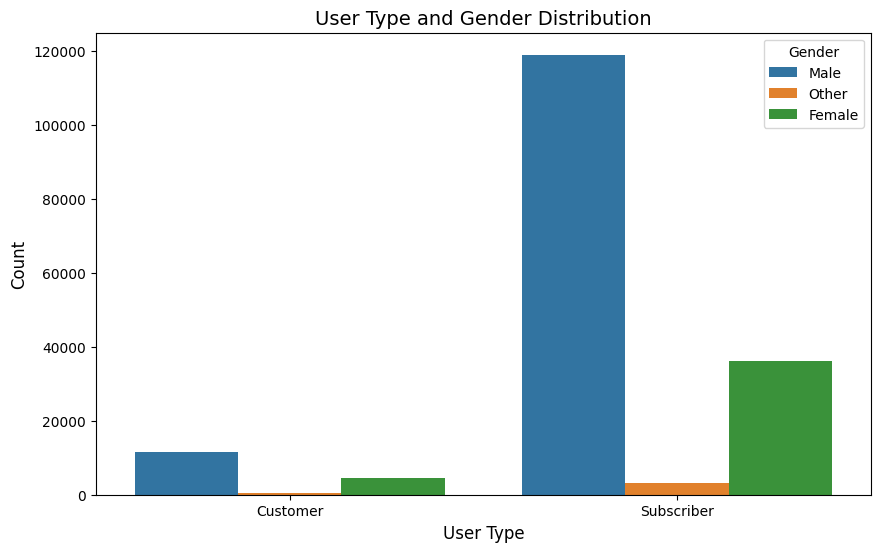

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='user_type', hue='member_gender')
plt.title('User Type and Gender Distribution', fontsize=14)
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Gender')
plt.show()

**Observation:**
Among both user types—Subscribers and Customers—male riders account for the highest number of trips. This trend is especially prominent among Subscribers, where the number of male users significantly exceeds that of female and other gender categories. Female riders represent the second-largest group, while the "Other" category has the fewest trips overall.

### Question 3: What is the relationship between trip duration and start station latitude?
What is the relationship between trip duration and start station latitude?

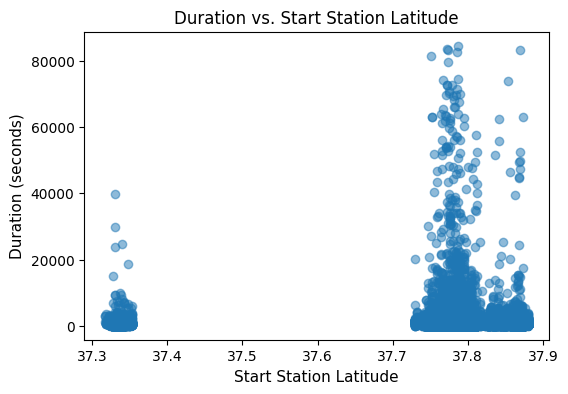

In [27]:
plt.figure(figsize=(6, 4))
plt.scatter(df['start_station_latitude'], df['duration_sec'], alpha=0.5)
plt.title('Duration vs. Start Station Latitude', fontsize=12)
plt.xlabel('Start Station Latitude', fontsize=11)
plt.ylabel('Duration (seconds)', fontsize=11)
plt.show()

**Observation:**
There appears to be no strong or consistent relationship between trip duration and the start station latitude. Trip durations are spread across a wide range of latitudes without any evident trend or clustering, suggesting that the geographical location (in terms of latitude) of a trip’s starting point does not significantly influence how long the trip lasts.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Observation:
Trip durations are generally shorter for Subscribers compared to Customers. This suggests that Subscribers—likely regular users—utilize the service for quick, routine commutes. In contrast, Customers, who are more likely casual or occasional users, tend to take longer rides, possibly for leisure or exploration.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Yes, several interesting relationships emerged during the analysis:

Start Hour vs. Trip Duration: Trips that began during off-peak hours—such as

*   early morning or late evening—tended to have longer durations. In contrast, trips starting during typical commuting hours (8–9 AM and 5–6 PM) were generally shorter. This pattern suggests that leisure or exploratory rides are more common outside of standard commuting times.

*   Start Station vs. Member Gender: Certain start stations showed a higher concentration of trips initiated by specific gender groups. This may reflect geographic, demographic, or cultural preferences influencing ridership patterns in different areas.

## Multivariate Exploration


### Question 1: How does trip duration relate to user age and bike share program participation?

Question: How does trip duration relate to user age and bike share program participation?

Calculate age from member_birth_year

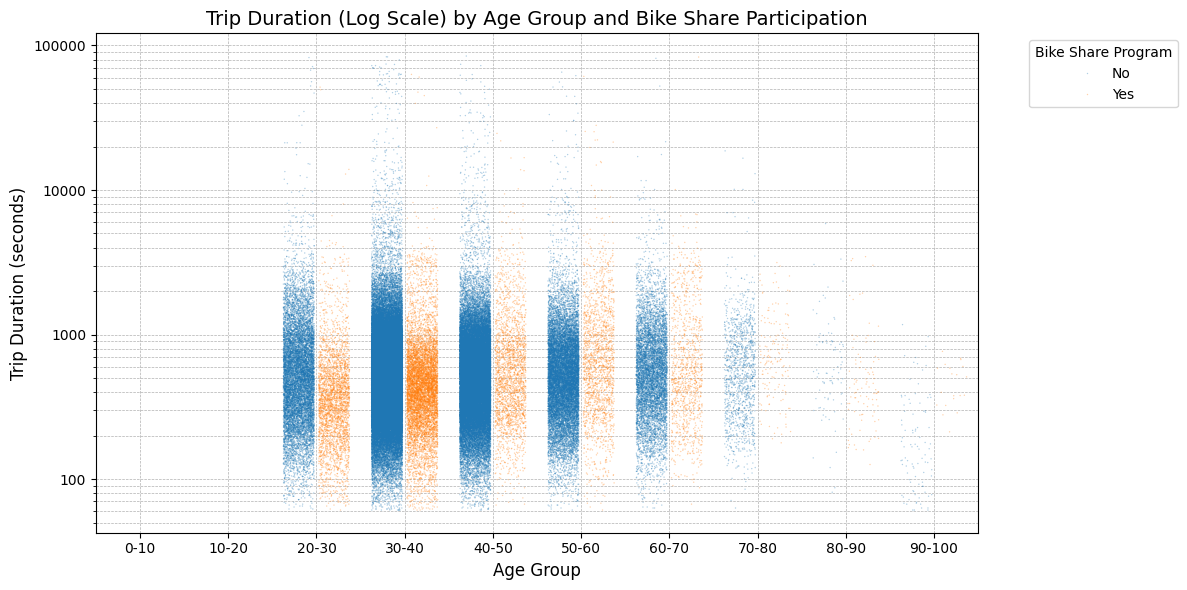

In [28]:
df['age'] = 2025 - df['member_birth_year']

# Drop missing or invalid values
df_filtered = df.dropna(subset=['age', 'duration_sec', 'bike_share_for_all_trip'])
df_filtered = df_filtered[df_filtered['duration_sec'] > 0]

# Define age bins
bins = list(range(0, 101, 10))
labels = [f'{i}-{i+10}' for i in bins[:-1]]
df_filtered['age_bin'] = pd.cut(df_filtered['age'], bins=bins, labels=labels, right=False)

# Plot using stripplot
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=df_filtered,
    x='age_bin',
    y='duration_sec',
    hue='bike_share_for_all_trip',
    dodge=True,
    jitter=0.35,
    size=1,
    alpha=0.35
)

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.title('Trip Duration (Log Scale) by Age Group and Bike Share Participation', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Trip Duration (seconds)', fontsize=12)
plt.legend(title='Bike Share Program', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

**Observation:**
The majority of bike share users fall within the 20–40 age range, indicating that younger adults are more likely to engage with the program. Older users exhibit greater variability in trip durations, with some taking very short rides and others much longer ones. Overall, most users tend to take relatively short trips, regardless of age group.

### Question 2: How does trip duration vary by gender and user type?

How does trip duration vary by gender and user type?

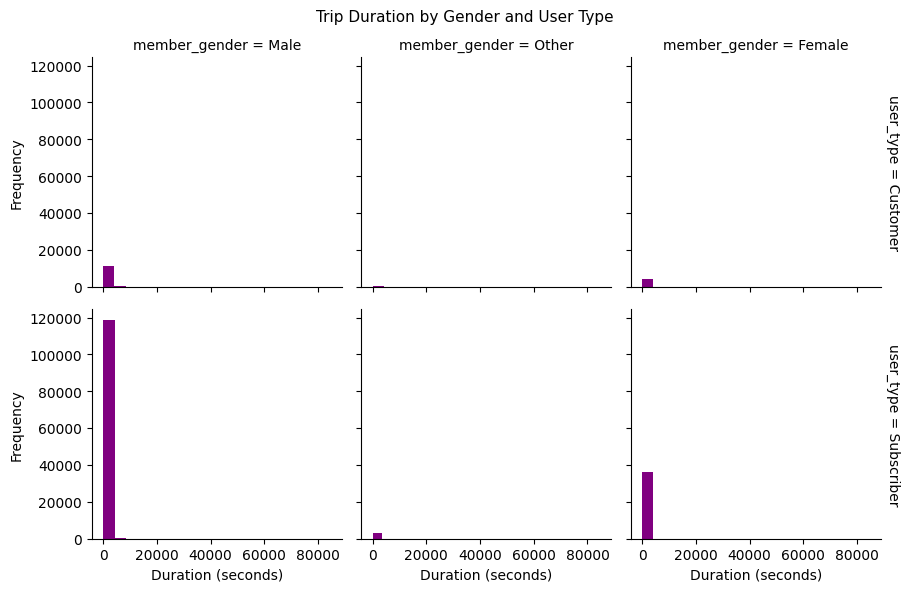

In [29]:
facet = sns.FacetGrid(df, col='member_gender', row='user_type', margin_titles=True)
facet.map(plt.hist, 'duration_sec', bins=20, color='purple')
facet.set_axis_labels('Duration (seconds)', 'Frequency')
facet.fig.subplots_adjust(top=0.9)
facet.fig.suptitle('Trip Duration by Gender and User Type', fontsize=11)
plt.show()


**Observation:**
**Trip Duration by User Type:**
Customers (top row) generally take longer trips than Subscribers (bottom row), as indicated by the broader spread of trip durations along the x-axis for Customers.

**Gender Comparison:**
Across all gender categories—Male, Female, and Other—Customers display more variability in trip durations, suggesting that their usage is more casual or leisure-oriented. In contrast, Subscribers tend to have shorter, more consistent trip durations, likely reflecting routine commuting behavior.

**Usage Frequency:**
Subscribers account for a significantly higher number of trips compared to Customers, as shown by the taller bars in the plots. This highlights their dominant role in the bike-share system’s daily usage.



### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> The interaction between trip duration, user type, and gender revealed meaningful behavioral patterns. Across all genders, Customers consistently recorded longer trip durations than Subscribers, suggesting they use the service more for recreational or leisurely purposes. In contrast, Subscribers tended to take shorter, more consistent trips, likely tied to routine, time-sensitive activities such as commuting. Gender differences were minimal in terms of trip duration patterns within each user type.

>A second key relationship emerged when analyzing trip duration, user age, and bike share program participation. Users aged 20 to 40 were the most active participants in the program and typically took shorter trips. This aligns with the notion that the bike share service primarily appeals to younger adults seeking convenient, quick transportation—especially for commuting. Older users showed more variability in trip durations, reflecting more diverse usage patterns.

### Were there any interesting or surprising interactions between features?

> Gender and User Type with Trip Duration:
Trip durations for Subscribers are consistently short and concentrated across all gender categories. This consistency suggests that Subscribers, regardless of demographic differences, engage in similar usage behavior—likely centered around routine, time-efficient travel such as commuting. In contrast, Customers tend to have more varied and longer trip durations, reflecting a more casual or recreational use.

>Bike Share Program Participation:
Users enrolled in the bike share program generally take shorter trips, indicating that the program may be designed to support frequent, short-term usage, possibly through incentives or limitations aimed at promoting efficiency.

>Age Outliers:
A small number of users appear to be over 100 years old, which is highly unlikely and likely the result of data entry errors. These cases emphasize the importance of data cleaning and validation when conducting exploratory analysis, especially with demographic fields like age.

## Conclusions
**Summary of Findings**

Subscribers take shorter, more consistent trips—likely for commuting—while Customers engage in longer, more varied rides, often for leisure.

Across all genders, Customers consistently show longer trip durations than Subscribers.

Younger users (20–40 years old) dominate the dataset, take shorter trips, and are more likely to participate in the bike share program.

Bike share participants tend to take shorter, frequent trips, suggesting the program is designed for quick, routine use.

A few extreme values (e.g., users over 100 years old or trips > 22 hours) were likely data entry errors and highlighted the importance of data cleaning.

**Exploration Reflection**

Univariate, bivariate, and multivariate visualizations helped uncover user behavior trends, while log scaling improved clarity in analyzing trip duration. Overall, user type and age are strong indicators of trip behavior in the Ford GoBike system.

In [30]:
!jupyter nbconvert --to html '/content/Part_I_exploration_template.ipynb' --output '/content/part_I_final_report.html'

[NbConvertApp] WARNING | pattern '/content/Part_I_exploration_template.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answe